# Minimum-gap probability heatmap under random Gaussian tilt

This notebook computes the probability that each pad becomes the **unique minimum-gap pad**.

Model:

$G_i = g_0 + d_i - (R_{t,i}+R_{b,i})$

and the target quantity is

$P_i = \Pr(G_i < G_j,\ \forall j\neq i)$.

No extra contact or arcing threshold is imposed.

Outputs:
- exact fixed-tilt solver
- analytical average heatmap under random Gaussian tilt
- Monte Carlo validation


In [8]:
#!/usr/bin/env python3
"""
Minimum-gap probability heatmap under random Gaussian tilt.

Model
-----
For pad i, define the instantaneous gap
    G_i = g0 + d_i - (R_{t,i} + R_{b,i}),

where
    R_{t,i} ~ N(mu_t, sigma_t^2),
    R_{b,i} ~ N(mu_b, sigma_b^2),
    d_i      = deterministic tilt-induced gap contribution,
    g0       = optional common nominal gap offset.

We only care about the probability that pad i is the unique minimum-gap pad:
    P_i = Pr(G_i < G_j for all j != i).

No extra contact or arcing window is imposed.

For fixed tilt, under independence across pad locations,

    P_i = ∫_{-∞}^{∞} f_i(g) ∏_{j != i} [1 - F_j(g)] dg,

where G_i ~ N(m_i, sigma^2), with
    m_i = g0 + d_i - (mu_t + mu_b),
    sigma^2 = sigma_t^2 + sigma_b^2.

This implementation supports:
1) exact O(QN) fixed-tilt solver
2) outer 2D Gauss-Hermite averaging over random Gaussian tilt
3) Monte Carlo validation by random sampling of dishing and tilt
"""

from __future__ import annotations

from dataclasses import dataclass, replace
import math
import time
from typing import List

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss
from numpy.polynomial.hermite import hermgauss
from scipy.special import log_ndtr


Array2D = np.ndarray


@dataclass
class Params:
    # Geometry
    die_size_x_mm: float = 5.0
    die_size_y_mm: float = 5.0
    pitch_um: float = 20.0

    # Fixed tilt (used in fixed-tilt mode)
    theta_x_deg: float = 0.0
    theta_y_deg: float = 0.0

    # Top/bottom height distributions
    mu_b_nm: float = 0.0
    sigma_b_nm: float = 1.0
    mu_t_nm: float = 0.0
    sigma_t_nm: float = 1.0

    # Common nominal gap offset
    global_gap_nm: float = 10.0

    # Inner quadrature for fixed-tilt exact map
    quadrature_points: int = 64
    tail_sigma: float = 8.0
    chunk_size: int = 100000
    renormalize_to_one: bool = True

    # Outer random tilt distribution
    mean_theta_x_deg: float = 0.0
    mean_theta_y_deg: float = 0.0
    sigma_theta_x_deg: float = 1.0e-4
    sigma_theta_y_deg: float = 2.0e-4
    outer_qx: int = 5
    outer_qy: int = 5

    # Monte Carlo
    mc_trials: int = 1000
    mc_batch_size: int = 8
    mc_seed: int = 0
    sample_sum_directly: bool = True

    # Plotting / saving
    show_plots: bool = True
    save_prefix: str = "minimum_gap_probability_random_tilt"
    max_plot_pixels: int = 1200

    def validate(self) -> None:
        if self.die_size_x_mm <= 0 or self.die_size_y_mm <= 0:
            raise ValueError("Die sizes must be positive.")
        if self.pitch_um <= 0:
            raise ValueError("Pitch must be positive.")
        if self.sigma_b_nm < 0 or self.sigma_t_nm < 0:
            raise ValueError("Standard deviations must be nonnegative.")
        if self.quadrature_points <= 0 or self.outer_qx <= 0 or self.outer_qy <= 0:
            raise ValueError("quadrature and outer quadrature counts must be positive.")
        if self.chunk_size <= 0 or self.mc_trials <= 0 or self.mc_batch_size <= 0:
            raise ValueError("chunk size and MC parameters must be positive.")


@dataclass
class Grid:
    rows: int
    cols: int
    x_mm: Array2D
    y_mm: Array2D
    gap_mean_nm: Array2D
    sigma_gap_nm: float
    favored_corner: str


@dataclass
class FixedResult:
    prob: Array2D
    prob_sum_before: float
    prob_sum_after: float


@dataclass
class AveragedResult:
    avg_prob: Array2D
    total_outer_weight: float
    grid: Grid


@dataclass
class MonteCarloResult:
    prob: Array2D
    trials: int
    grid: Grid


def build_grid(params: Params) -> Grid:
    params.validate()

    rows = int(round(params.die_size_y_mm * 1000.0 / params.pitch_um))
    cols = int(round(params.die_size_x_mm * 1000.0 / params.pitch_um))
    if rows <= 0 or cols <= 0:
        raise ValueError("Computed grid size is non-positive. Check die size and pitch.")

    pitch_mm = params.pitch_um / 1000.0
    x_coords_mm = (np.arange(cols) - (cols - 1) / 2.0) * pitch_mm
    y_coords_mm = (np.arange(rows) - (rows - 1) / 2.0) * pitch_mm
    x_mm, y_mm = np.meshgrid(x_coords_mm, y_coords_mm, indexing="xy")

    tx = math.tan(math.radians(params.theta_x_deg))
    ty = math.tan(math.radians(params.theta_y_deg))
    deterministic_gap_nm = 1.0e6 * (x_mm * tx + y_mm * ty)

    mu_h = params.mu_t_nm + params.mu_b_nm
    gap_mean_nm = params.global_gap_nm + deterministic_gap_nm - mu_h
    sigma_gap_nm = math.sqrt(params.sigma_t_nm**2 + params.sigma_b_nm**2)
    if sigma_gap_nm == 0:
        raise ValueError("Combined sigma is zero. At least one sigma must be positive.")

    favored_corner = determine_favored_corner(tx, ty)

    return Grid(
        rows=rows,
        cols=cols,
        x_mm=x_mm,
        y_mm=y_mm,
        gap_mean_nm=gap_mean_nm,
        sigma_gap_nm=sigma_gap_nm,
        favored_corner=favored_corner,
    )


def determine_favored_corner(tx: float, ty: float) -> str:
    row = 0 if ty >= 0 else 1
    col = 0 if tx >= 0 else 1
    if row == 0 and col == 0:
        return "bottom_left"
    if row == 0 and col == 1:
        return "bottom_right"
    if row == 1 and col == 0:
        return "top_left"
    return "top_right"


def legendre_quadrature_interval(q: int, low: float, high: float):
    x, w = leggauss(q)
    g = 0.5 * (x + 1.0) * (high - low) + low
    wg = 0.5 * (high - low) * w
    return g.astype(np.float64), wg.astype(np.float64)


def choose_effective_interval(mean_flat: np.ndarray, sigma: float, tail_sigma: float):
    low = float(mean_flat.min() - tail_sigma * sigma)
    high = float(mean_flat.max() + tail_sigma * sigma)
    return low, high


def evaluate_fixed_tilt_minimum_gap_map(params: Params, grid: Grid, verbose: bool = False) -> FixedResult:
    mean_flat = grid.gap_mean_nm.ravel().astype(np.float64, copy=False)
    sigma = float(grid.sigma_gap_nm)
    n = mean_flat.size

    low, high = choose_effective_interval(mean_flat, sigma, params.tail_sigma)
    g_nodes, g_weights = legendre_quadrature_interval(params.quadrature_points, low, high)

    prob_flat = np.zeros_like(mean_flat, dtype=np.float64)

    t0 = time.time()
    for k, (g, w) in enumerate(zip(g_nodes, g_weights), start=1):
        total_log_survival = 0.0
        for start in range(0, n, params.chunk_size):
            end = min(start + params.chunk_size, n)
            mu_chunk = mean_flat[start:end]
            total_log_survival += float(log_ndtr((mu_chunk - g) / sigma).sum())

        logw = math.log(float(w))
        for start in range(0, n, params.chunk_size):
            end = min(start + params.chunk_size, n)
            mu_chunk = mean_flat[start:end]

            t = (g - mu_chunk) / sigma
            logf = -0.5 * t * t - math.log(sigma) - 0.5 * math.log(2.0 * math.pi)
            log_survival = log_ndtr((mu_chunk - g) / sigma)

            log_integrand = logw + logf + total_log_survival - log_survival
            prob_flat[start:end] += np.exp(log_integrand)

        if verbose:
            elapsed = time.time() - t0
            print(f"[inner O(QN)] quadrature {k}/{len(g_nodes)} done, elapsed={elapsed:.2f}s")

    prob_sum_before = float(prob_flat.sum())
    if params.renormalize_to_one and prob_sum_before > 0:
        prob_flat /= prob_sum_before
    prob_sum_after = float(prob_flat.sum())

    return FixedResult(
        prob=prob_flat.reshape(grid.rows, grid.cols),
        prob_sum_before=prob_sum_before,
        prob_sum_after=prob_sum_after,
    )


def average_minimum_gap_map_over_random_tilt(params: Params, verbose: bool = True) -> AveragedResult:
    x_nodes, x_weights = hermgauss(params.outer_qx)
    y_nodes, y_weights = hermgauss(params.outer_qy)

    avg_prob = None
    total_outer_weight = 0.0
    ref_grid = None

    total_cases = params.outer_qx * params.outer_qy
    case_id = 0
    t0 = time.time()

    for xa, wa in zip(x_nodes, x_weights):
        theta_x = params.mean_theta_x_deg + math.sqrt(2.0) * params.sigma_theta_x_deg * float(xa)

        for yb, vb in zip(y_nodes, y_weights):
            theta_y = params.mean_theta_y_deg + math.sqrt(2.0) * params.sigma_theta_y_deg * float(yb)

            p_case = replace(params, theta_x_deg=float(theta_x), theta_y_deg=float(theta_y))
            grid_case = build_grid(p_case)
            res_case = evaluate_fixed_tilt_minimum_gap_map(p_case, grid_case, verbose=False)

            coeff = float(wa * vb / math.pi)

            if avg_prob is None:
                avg_prob = coeff * res_case.prob
                ref_grid = grid_case
            else:
                avg_prob += coeff * res_case.prob

            total_outer_weight += coeff
            case_id += 1
            if verbose:
                elapsed = time.time() - t0
                print(
                    f"[outer GH] {case_id}/{total_cases} | "
                    f"theta_x={theta_x:.3e} deg, theta_y={theta_y:.3e} deg | "
                    f"elapsed={elapsed:.2f}s"
                )

    # normalize again to remove tiny quadrature / numerical drift
    s = float(avg_prob.sum())
    if s > 0:
        avg_prob /= s

    return AveragedResult(
        avg_prob=avg_prob,
        total_outer_weight=float(total_outer_weight),
        grid=ref_grid,
    )


def monte_carlo_minimum_gap_map(params: Params, verbose: bool = True) -> MonteCarloResult:
    rng = np.random.default_rng(params.mc_seed)

    base_params = replace(params, theta_x_deg=params.mean_theta_x_deg, theta_y_deg=params.mean_theta_y_deg)
    grid = build_grid(base_params)
    rows, cols = grid.rows, grid.cols
    x_mm = grid.x_mm
    y_mm = grid.y_mm

    counts = np.zeros(rows * cols, dtype=np.int64)

    mu_h = params.mu_t_nm + params.mu_b_nm
    sigma_h = math.sqrt(params.sigma_t_nm**2 + params.sigma_b_nm**2)

    total_trials = params.mc_trials
    done = 0
    t0 = time.time()

    while done < total_trials:
        batch = min(params.mc_batch_size, total_trials - done)

        theta_x_batch = rng.normal(params.mean_theta_x_deg, params.sigma_theta_x_deg, size=batch)
        theta_y_batch = rng.normal(params.mean_theta_y_deg, params.sigma_theta_y_deg, size=batch)

        tx = np.tan(np.deg2rad(theta_x_batch))[:, None, None]
        ty = np.tan(np.deg2rad(theta_y_batch))[:, None, None]
        deterministic_gap = params.global_gap_nm + 1.0e6 * (x_mm[None, :, :] * tx + y_mm[None, :, :] * ty)

        if params.sample_sum_directly:
            H = rng.normal(mu_h, sigma_h, size=(batch, rows, cols))
        else:
            Rb = rng.normal(params.mu_b_nm, params.sigma_b_nm, size=(batch, rows, cols))
            Rt = rng.normal(params.mu_t_nm, params.sigma_t_nm, size=(batch, rows, cols))
            H = Rb + Rt

        G = deterministic_gap - H
        G_flat = G.reshape(batch, -1)

        min_idx = np.argmin(G_flat, axis=1)
        np.add.at(counts, min_idx, 1)

        done += batch
        if verbose:
            elapsed = time.time() - t0
            print(f"[MC] {done}/{total_trials} trials done, elapsed={elapsed:.2f}s")

    prob = counts.reshape(rows, cols) / total_trials

    return MonteCarloResult(
        prob=prob,
        trials=int(total_trials),
        grid=grid,
    )


def compare_analytical_and_mc(avg_result: AveragedResult, mc_result: MonteCarloResult) -> str:
    diff = avg_result.avg_prob - mc_result.prob
    l1 = float(np.abs(diff).sum())
    l2 = float(np.sqrt(np.sum(diff**2)))

    lines = []
    lines.append("Analytical vs Monte Carlo comparison")
    lines.append(f"- L1 difference = {l1:.12e}")
    lines.append(f"- L2 difference = {l2:.12e}")
    return "\n".join(lines)


def downsample_for_plot(arr: Array2D, x_mm: Array2D, y_mm: Array2D, max_pixels: int):
    rows, cols = arr.shape
    step_r = max(1, int(math.ceil(rows / max_pixels)))
    step_c = max(1, int(math.ceil(cols / max_pixels)))
    return arr[::step_r, ::step_c], x_mm[::step_r, ::step_c], y_mm[::step_r, ::step_c]


def plot_probability_map(prob: Array2D, grid: Grid, params: Params, prefix: str, title_prefix: str) -> List[str]:
    out_files = []

    prob_ds, x_ds, y_ds = downsample_for_plot(prob, grid.x_mm, grid.y_mm, params.max_plot_pixels)
    extent = [
        x_ds[0, 0] - params.pitch_um / 2000.0,
        x_ds[0, -1] + params.pitch_um / 2000.0,
        y_ds[0, 0] - params.pitch_um / 2000.0,
        y_ds[-1, 0] + params.pitch_um / 2000.0,
    ]

    fig = plt.figure(figsize=(7, 6))
    plt.imshow(prob_ds, origin="lower", extent=extent, interpolation="nearest", aspect="equal")
    plt.colorbar(label="Probability per pad")
    plt.xlabel("x (mm)")
    plt.ylabel("y (mm)")
    plt.title(f"{title_prefix}")
    plt.tight_layout()
    f1 = f"{prefix}_linear.png"
    plt.savefig(f1, dpi=200, bbox_inches="tight")
    out_files.append(f1)
    if params.show_plots:
        plt.show()
    else:
        plt.close(fig)

    return out_files


def summarize_average_result(result: AveragedResult, params: Params) -> str:
    grid = result.grid
    idx = np.unravel_index(np.argmax(result.avg_prob), result.avg_prob.shape)
    max_prob = float(result.avg_prob[idx])
    max_x = float(grid.x_mm[idx])
    max_y = float(grid.y_mm[idx])

    lines = []
    lines.append("Average minimum-gap probability heatmap under random Gaussian tilt")
    lines.append("")
    lines.append("Base parameters")
    lines.append(f"- die_size_x_mm = {params.die_size_x_mm}")
    lines.append(f"- die_size_y_mm = {params.die_size_y_mm}")
    lines.append(f"- pitch_um = {params.pitch_um}")
    lines.append(f"- rows x cols = {grid.rows} x {grid.cols}")
    lines.append(f"- total pads = {grid.rows * grid.cols}")
    lines.append(f"- mu_b_nm = {params.mu_b_nm}")
    lines.append(f"- sigma_b_nm = {params.sigma_b_nm}")
    lines.append(f"- mu_t_nm = {params.mu_t_nm}")
    lines.append(f"- sigma_t_nm = {params.sigma_t_nm}")
    lines.append(f"- global_gap_nm = {params.global_gap_nm}")
    lines.append(f"- sigma_gap_nm = {grid.sigma_gap_nm:.6f}")
    lines.append("")
    lines.append("Random tilt distribution")
    lines.append(f"- mean_theta_x_deg = {params.mean_theta_x_deg}")
    lines.append(f"- mean_theta_y_deg = {params.mean_theta_y_deg}")
    lines.append(f"- sigma_theta_x_deg = {params.sigma_theta_x_deg}")
    lines.append(f"- sigma_theta_y_deg = {params.sigma_theta_y_deg}")
    lines.append(f"- outer_qx = {params.outer_qx}")
    lines.append(f"- outer_qy = {params.outer_qy}")
    lines.append(f"- total_outer_weight = {result.total_outer_weight:.12f}")
    lines.append("")
    lines.append("Result")
    lines.append(f"- probability sum = {result.avg_prob.sum():.12f}")
    lines.append(f"- max pad index = {idx}")
    lines.append(f"- max pad location (mm) = ({max_x:.6f}, {max_y:.6f})")
    lines.append(f"- max probability = {max_prob:.12e}")

    return "\n".join(lines)


def summarize_mc_result(result: MonteCarloResult) -> str:
    idx = np.unravel_index(np.argmax(result.prob), result.prob.shape)
    max_prob = float(result.prob[idx])

    lines = []
    lines.append("Monte Carlo minimum-gap result")
    lines.append(f"- trials = {result.trials}")
    lines.append(f"- probability sum = {result.prob.sum():.12f}")
    lines.append(f"- max pad index = {idx}")
    lines.append(f"- max probability = {max_prob:.12e}")
    return "\n".join(lines)




In [9]:
params = Params(
    die_size_x_mm=10.0,
    die_size_y_mm=10.0,
    pitch_um=100.0,
    mu_b_nm=0.0,
    sigma_b_nm=1.0,
    mu_t_nm=0.0,
    sigma_t_nm=1.0,
    global_gap_nm=10.0,
    quadrature_points=64,
    tail_sigma=8.0,
    chunk_size=100000,
    renormalize_to_one=True,
    mean_theta_x_deg=0.0,
    mean_theta_y_deg=0.0,
    sigma_theta_x_deg=1.0e-5,
    sigma_theta_y_deg=2.0e-5,
    outer_qx=7,
    outer_qy=7,
    mc_trials=1000,
    mc_batch_size=8,
    mc_seed=0,
    sample_sum_directly=True,
    show_plots=True,
    save_prefix='minimum_gap_probability_random_tilt_notebook',
    max_plot_pixels=1200,
)


## Analytical average under random tilt


In [10]:
t0 = time.time()
avg_result = average_minimum_gap_map_over_random_tilt(params, verbose=True)
t1 = time.time()
print(f'Analytical average evaluation finished in {t1 - t0:.2f}s')
print(summarize_average_result(avg_result, params))


[outer GH] 1/49 | theta_x=-3.750e-05 deg, theta_y=-7.501e-05 deg | elapsed=0.05s
[outer GH] 2/49 | theta_x=-3.750e-05 deg, theta_y=-4.734e-05 deg | elapsed=0.10s
[outer GH] 3/49 | theta_x=-3.750e-05 deg, theta_y=-2.309e-05 deg | elapsed=0.16s
[outer GH] 4/49 | theta_x=-3.750e-05 deg, theta_y=0.000e+00 deg | elapsed=0.21s
[outer GH] 5/49 | theta_x=-3.750e-05 deg, theta_y=2.309e-05 deg | elapsed=0.26s
[outer GH] 6/49 | theta_x=-3.750e-05 deg, theta_y=4.734e-05 deg | elapsed=0.32s
[outer GH] 7/49 | theta_x=-3.750e-05 deg, theta_y=7.501e-05 deg | elapsed=0.37s
[outer GH] 8/49 | theta_x=-2.367e-05 deg, theta_y=-7.501e-05 deg | elapsed=0.42s
[outer GH] 9/49 | theta_x=-2.367e-05 deg, theta_y=-4.734e-05 deg | elapsed=0.47s
[outer GH] 10/49 | theta_x=-2.367e-05 deg, theta_y=-2.309e-05 deg | elapsed=0.52s
[outer GH] 11/49 | theta_x=-2.367e-05 deg, theta_y=0.000e+00 deg | elapsed=0.57s
[outer GH] 12/49 | theta_x=-2.367e-05 deg, theta_y=2.309e-05 deg | elapsed=0.63s
[outer GH] 13/49 | theta_x=-2.3

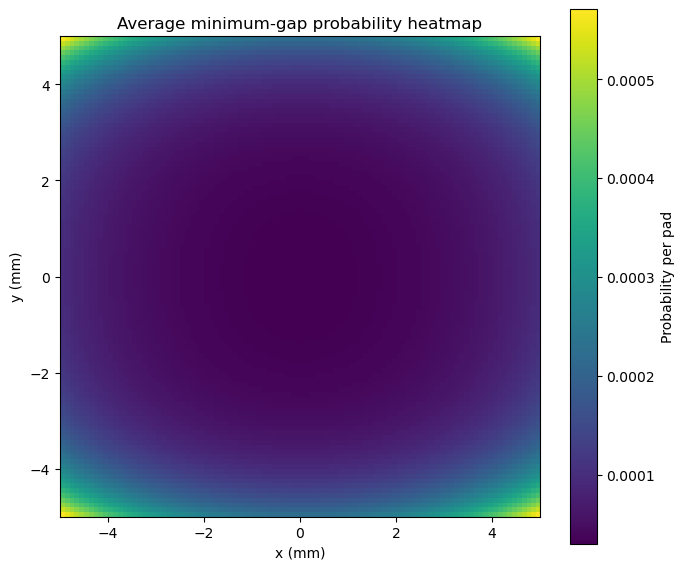

['minimum_gap_probability_random_tilt_notebook_analytical_linear.png']

In [11]:
plot_probability_map(
    prob=avg_result.avg_prob,
    grid=avg_result.grid,
    params=params,
    prefix='minimum_gap_probability_random_tilt_notebook_analytical',
    title_prefix='Average minimum-gap probability heatmap',
)


## Monte Carlo validation


In [ ]:
t0 = time.time()
mc_result = monte_carlo_minimum_gap_map(params, verbose=True)
t1 = time.time()
print(f'Monte Carlo finished in {t1 - t0:.2f}s')
print(summarize_mc_result(mc_result))


In [ ]:
plot_probability_map(
    prob=mc_result.prob,
    grid=mc_result.grid,
    params=params,
    prefix='minimum_gap_probability_random_tilt_notebook_mc',
    title_prefix='Monte Carlo minimum-gap probability heatmap',
)


## Analytical vs Monte Carlo comparison


In [ ]:
print(compare_analytical_and_mc(avg_result, mc_result))
